
Random_state:  69
        C-V2-E  PIC
23     45000.0   20
15    800000.0    3
25  10000000.0    9
9       2580.0    0
10     14218.0   20
6       1200.0    4
16   1500000.0   17
[[0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]
              precision    recall  f1-score   support

     healing       1.00      1.00      1.00         3
 Not-healing       1.00      1.00      1.00         4

   micro avg       1.00      1.00      1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7
 samples avg       1.00      1.00      1.00         7



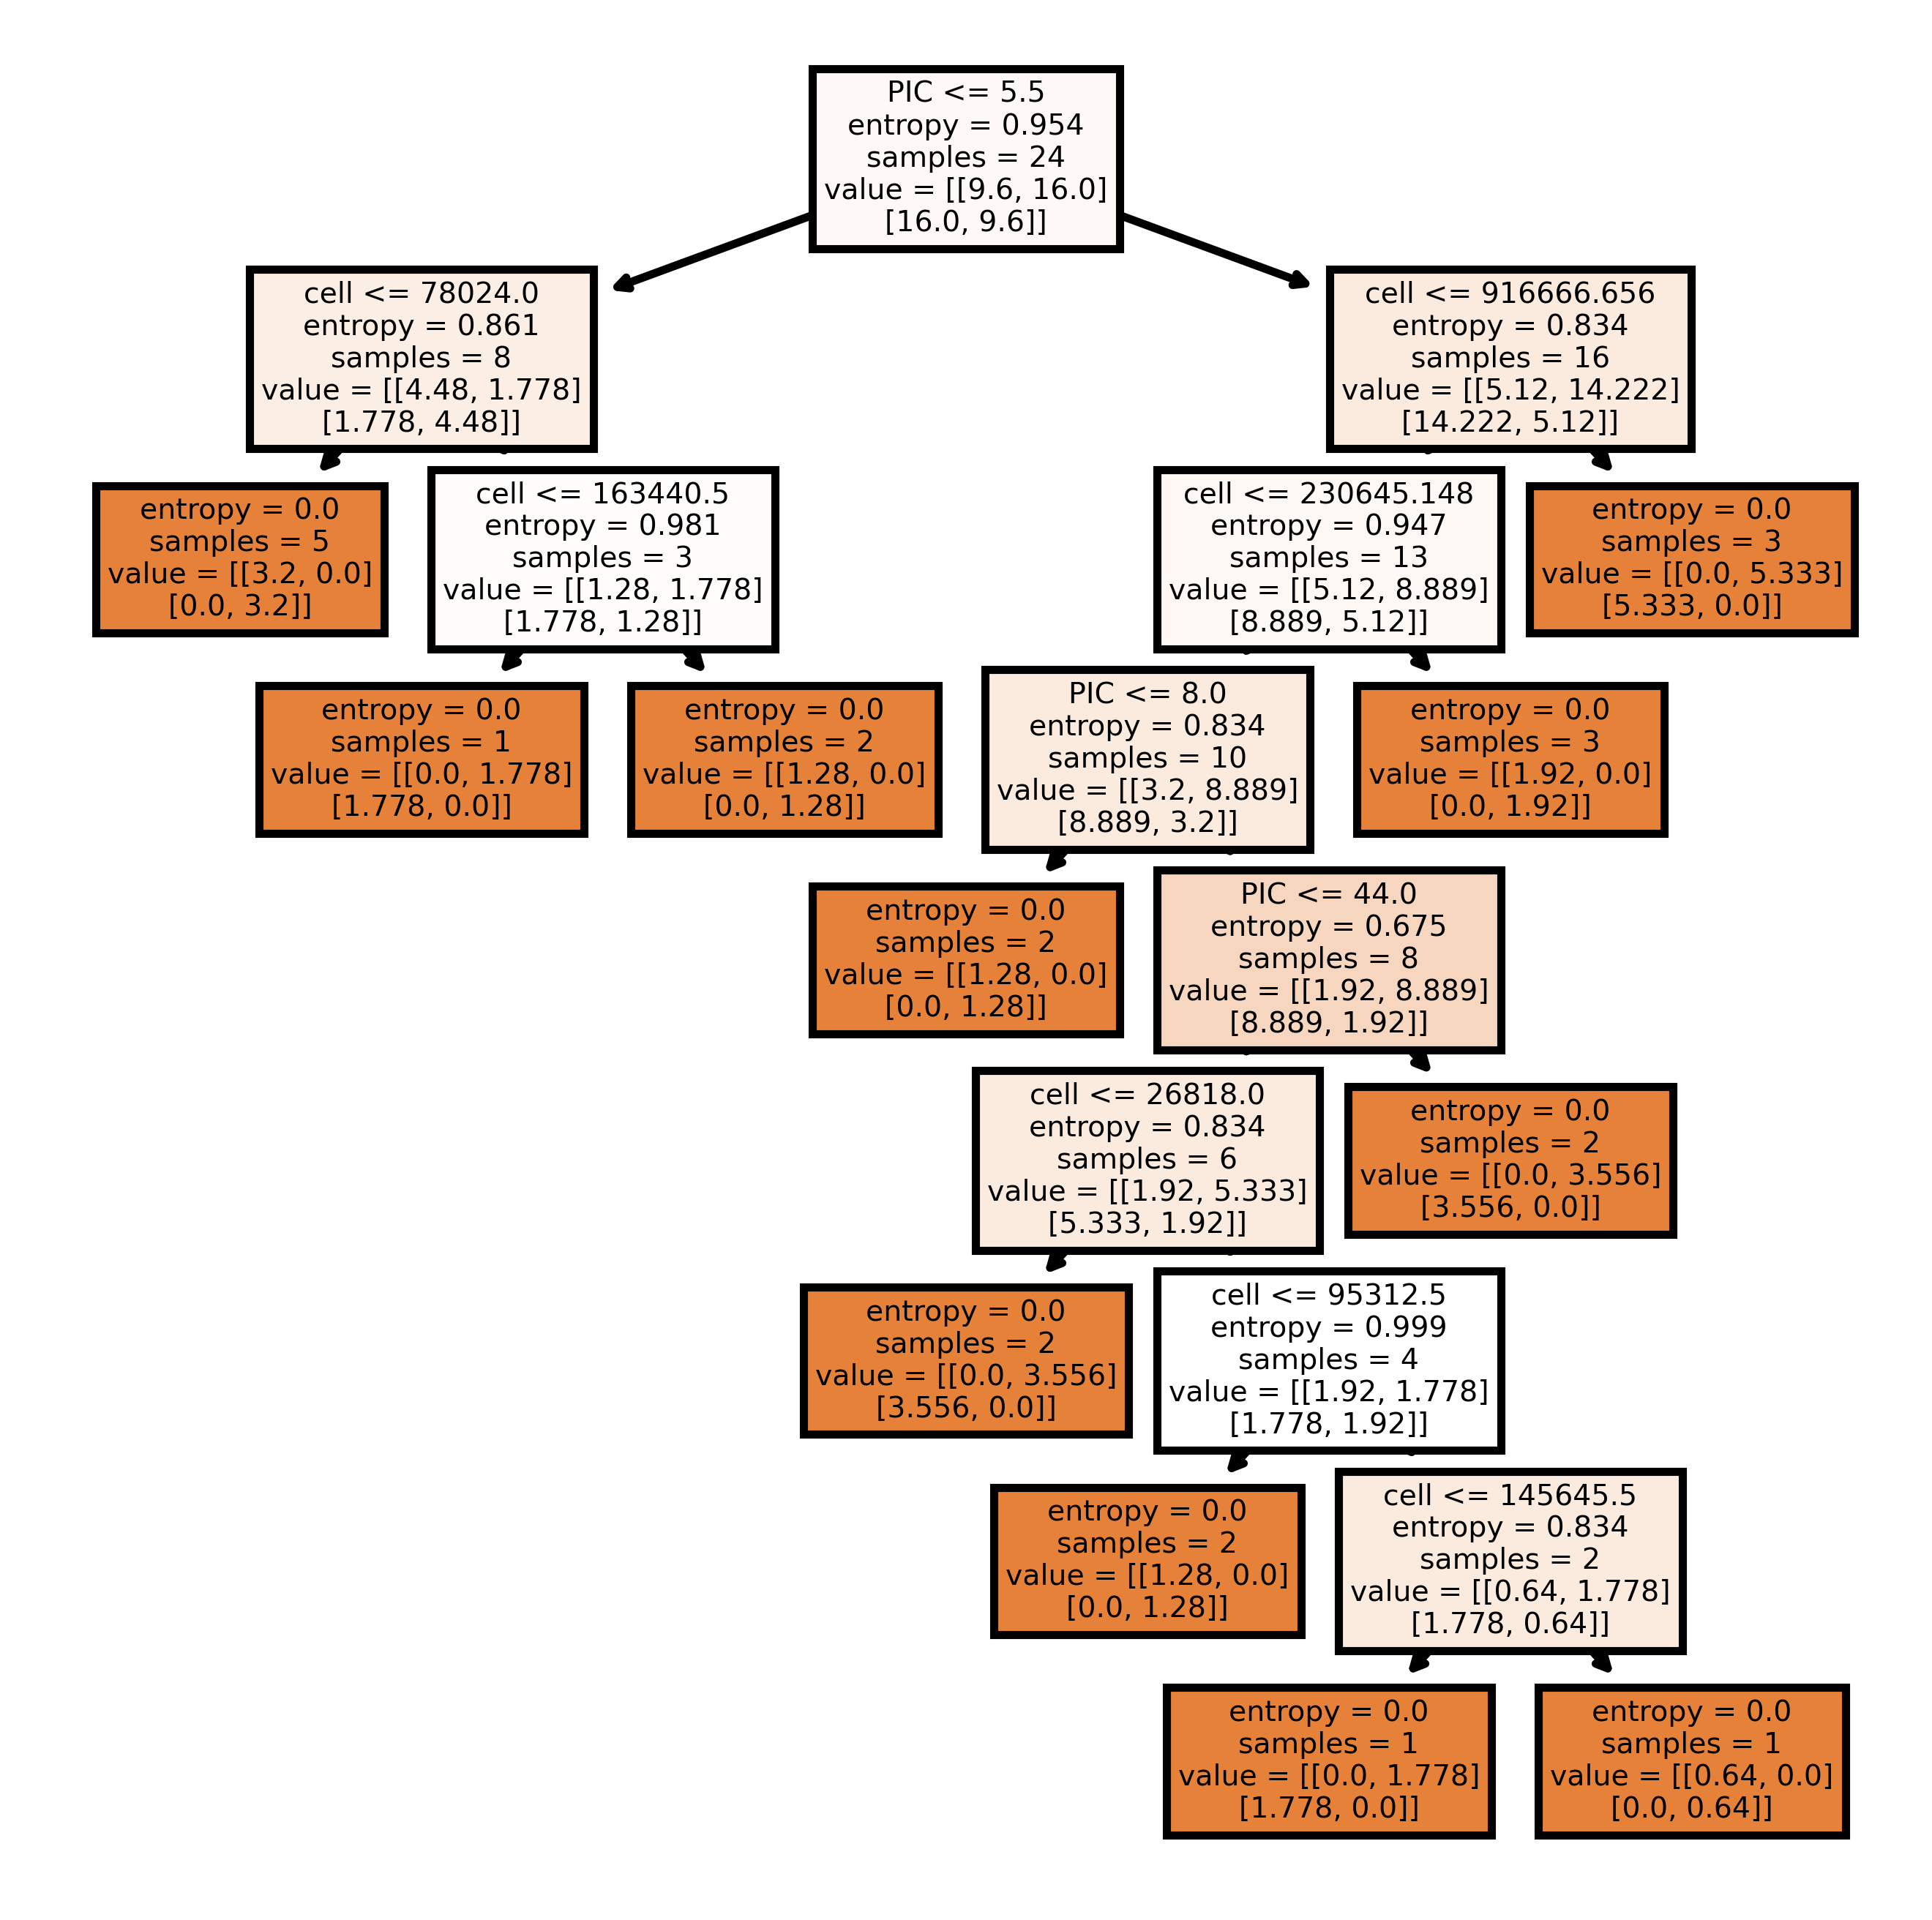

Accuracy: 100.0 %


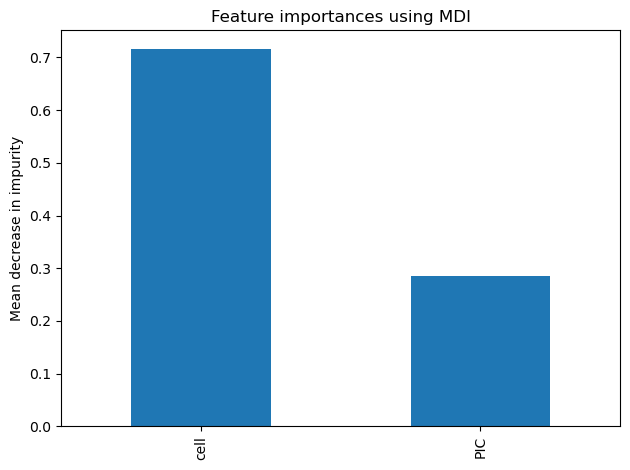

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier

Treatment=pd.read_csv("../dissertation/PIC cell.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=4
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.2, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print(X_test)
print(y_test)

clf=DecisionTreeClassifier(max_depth=None,
                            class_weight="balanced",
                               criterion="entropy",
                               ccp_alpha=0.06,
                  
    )

names=["cell","PIC"]

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["healing","Not-healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
tree.plot_tree(clf, filled = True,feature_names=names);
plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()
target = 'key'
class_names=["non-healing","healing"]

from supertree import SuperTree
st = SuperTree(
    clf, 
    df_x, 
    df_y, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree()